<a href="https://colab.research.google.com/github/RAGHAVJINDGER/Exploratory-Data-Analysis/blob/main/Experiment_7_15-08-26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving powerconsumption.csv to powerconsumption.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv('/content/powerconsumption.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [4]:
print(df.shape)
print(df.info())

(52416, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Datetime                52416 non-null  datetime64[ns]
 1   Temperature             52416 non-null  float64       
 2   Humidity                52416 non-null  float64       
 3   WindSpeed               52416 non-null  float64       
 4   GeneralDiffuseFlows     52416 non-null  float64       
 5   DiffuseFlows            52416 non-null  float64       
 6   PowerConsumption_Zone1  52416 non-null  float64       
 7   PowerConsumption_Zone2  52416 non-null  float64       
 8   PowerConsumption_Zone3  52416 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.6 MB
None


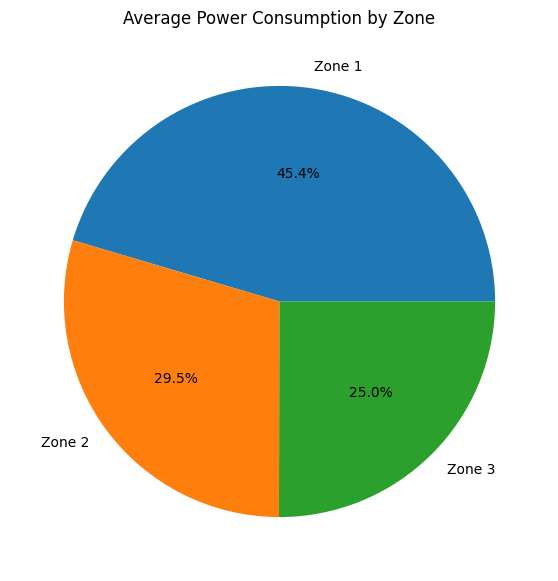

In [5]:
zone_avg = [
    df['PowerConsumption_Zone1'].mean(),
    df['PowerConsumption_Zone2'].mean(),
    df['PowerConsumption_Zone3'].mean()
]

labels = ['Zone 1', 'Zone 2', 'Zone 3']

plt.figure(figsize=(7, 7))
plt.pie(zone_avg, labels=labels, autopct='%1.1f%%')
plt.title('Average Power Consumption by Zone')
plt.show()

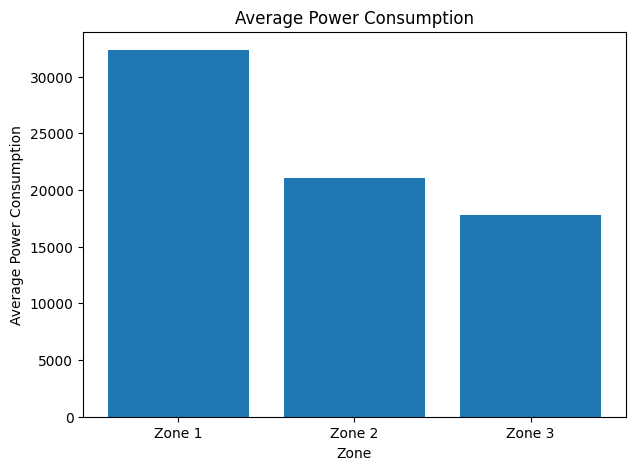

In [6]:
zones = ['Zone 1', 'Zone 2', 'Zone 3']

values = [
    df['PowerConsumption_Zone1'].mean(),
    df['PowerConsumption_Zone2'].mean(),
    df['PowerConsumption_Zone3'].mean()
]

plt.figure(figsize=(7, 5))
plt.bar(zones, values)
plt.xlabel('Zone')
plt.ylabel('Average Power Consumption')
plt.title('Average Power Consumption')
plt.show()

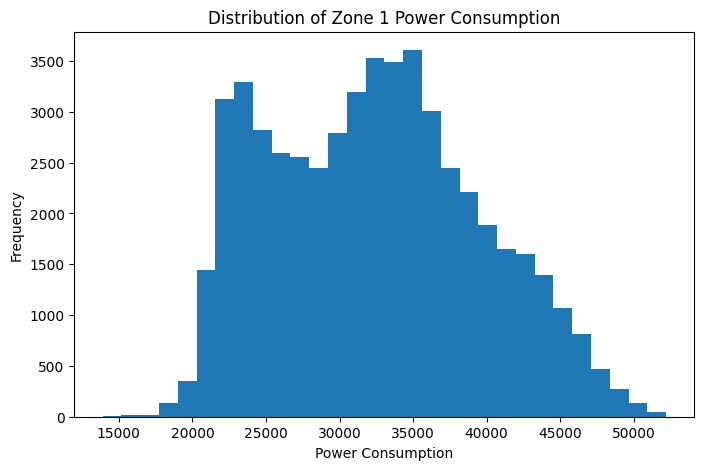

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df['PowerConsumption_Zone1'], bins=30)
plt.xlabel('Power Consumption')
plt.ylabel('Frequency')
plt.title('Distribution of Zone 1 Power Consumption')
plt.show()

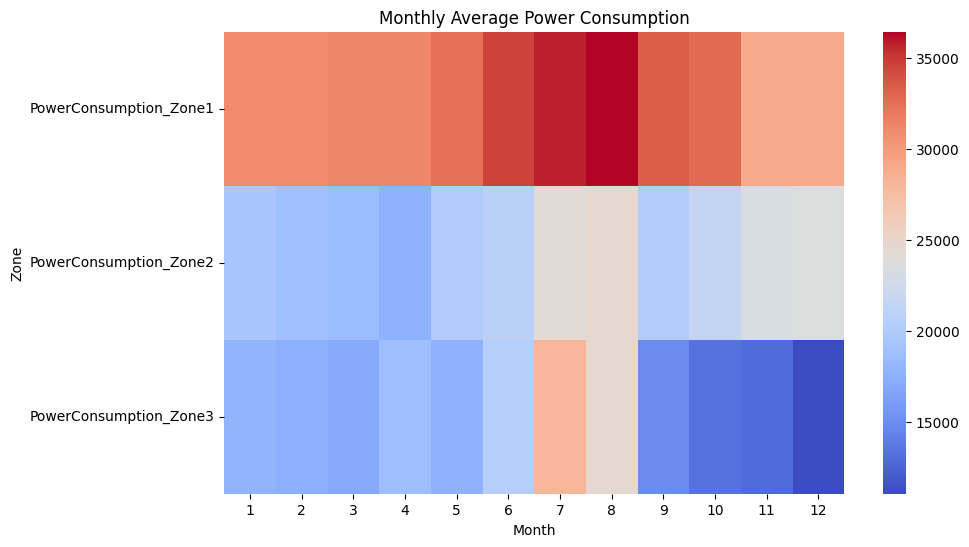

In [8]:
df['Month'] = df['Datetime'].dt.month

monthly_power = df.groupby('Month')[
    ['PowerConsumption_Zone1',
     'PowerConsumption_Zone2',
     'PowerConsumption_Zone3']
].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(monthly_power.T, annot=False, cmap='coolwarm')
plt.xlabel('Month')
plt.ylabel('Zone')
plt.title('Monthly Average Power Consumption')
plt.show()

In [9]:
import plotly.express as px

map_data = pd.DataFrame({
    'country': ['India', 'USA', 'UK', 'Australia'],
    'value': [500, 400, 300, 200]
})

fig = px.choropleth(
    map_data,
    locations='country',
    locationmode='country names',
    color='value',
    title='Sample Choropleth Map'
)

fig.show()

In [10]:
!pip install wordcloud

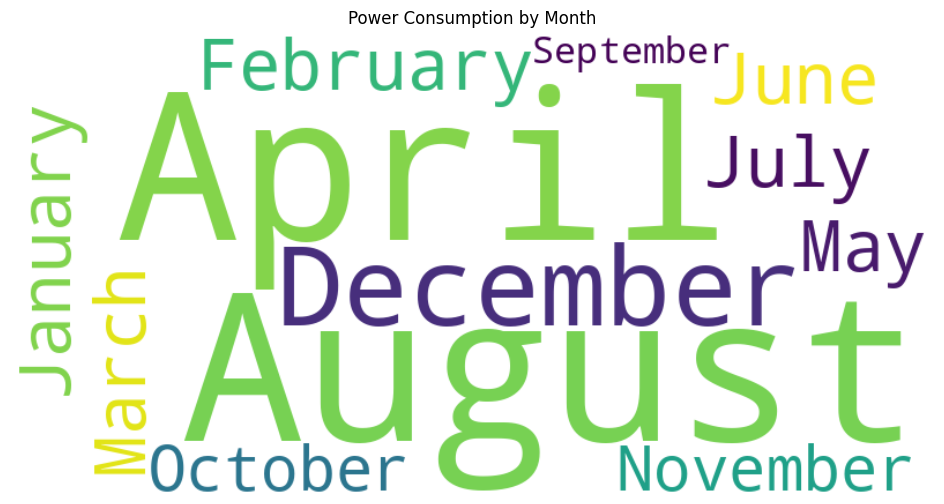

In [11]:
from wordcloud import WordCloud

df['MonthName'] = df['Datetime'].dt.month_name()

month_power = df.groupby('MonthName')['PowerConsumption_Zone1'].mean()

text = ' '.join(
    [month + ' ' * max(1, int(value / 500))
     for month, value in month_power.items()]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Power Consumption by Month')
plt.show()

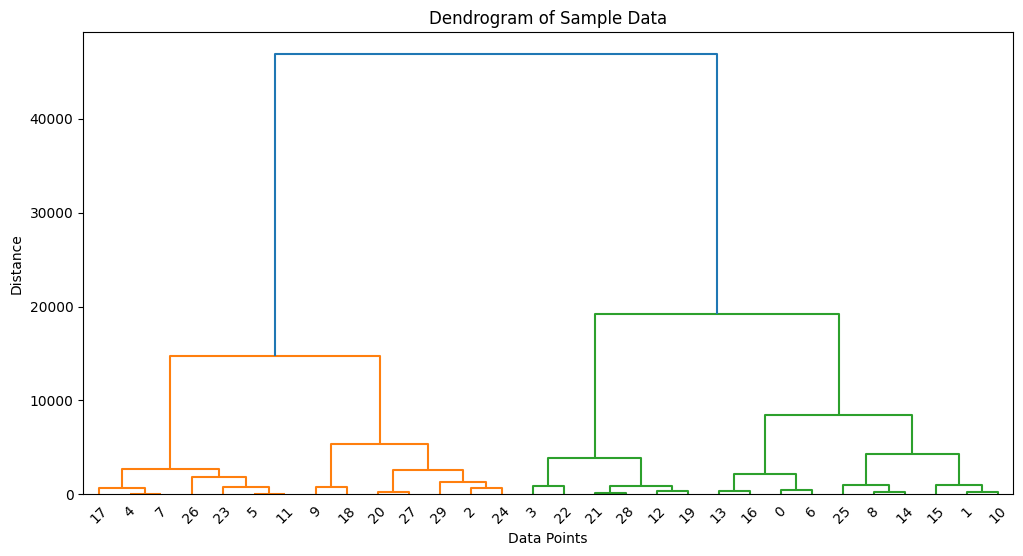

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

sample = df[
    ['Temperature',
     'Humidity',
     'WindSpeed',
     'PowerConsumption_Zone1']
].sample(30, random_state=42)

linked = linkage(sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title('Dendrogram of Sample Data')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

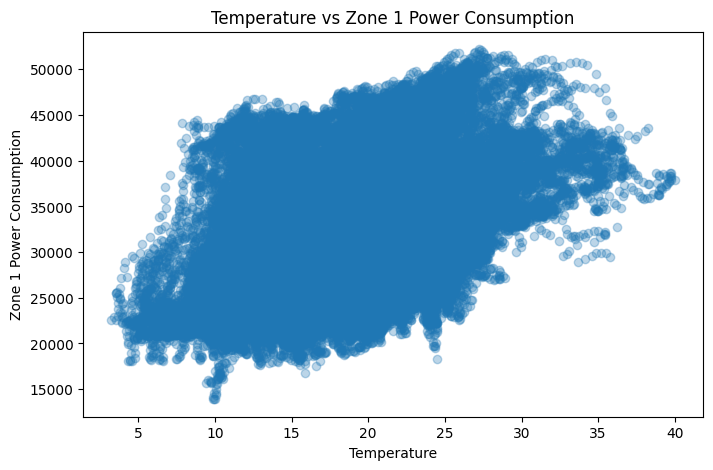

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['Temperature'],
    df['PowerConsumption_Zone1'],
    alpha=0.3
)

plt.xlabel('Temperature')
plt.ylabel('Zone 1 Power Consumption')
plt.title('Temperature vs Zone 1 Power Consumption')
plt.show()

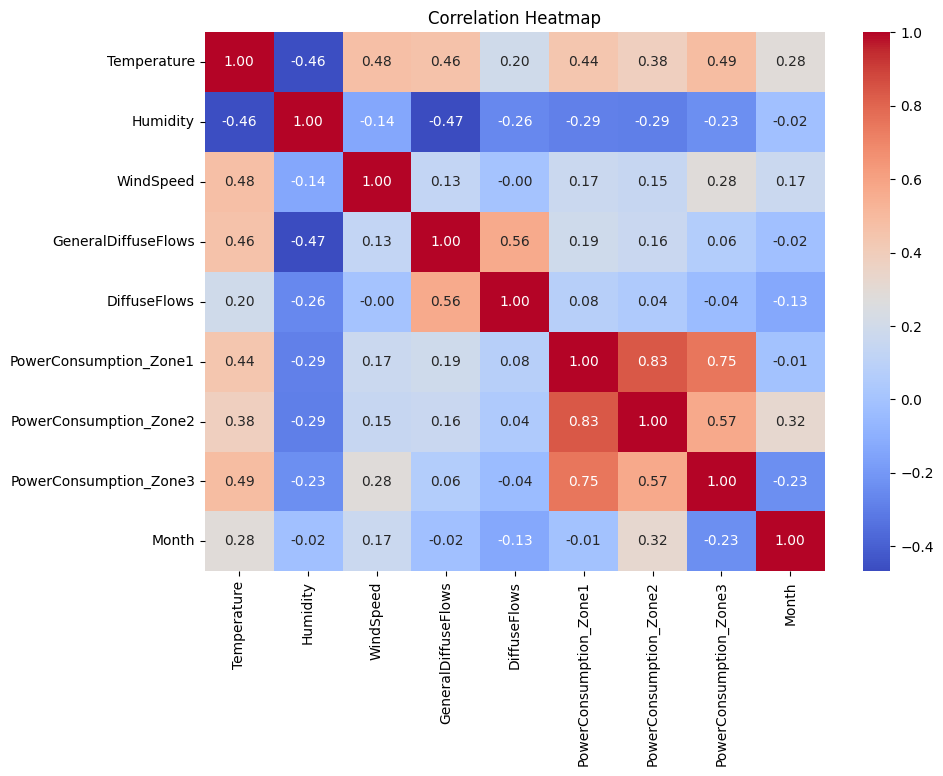

In [14]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

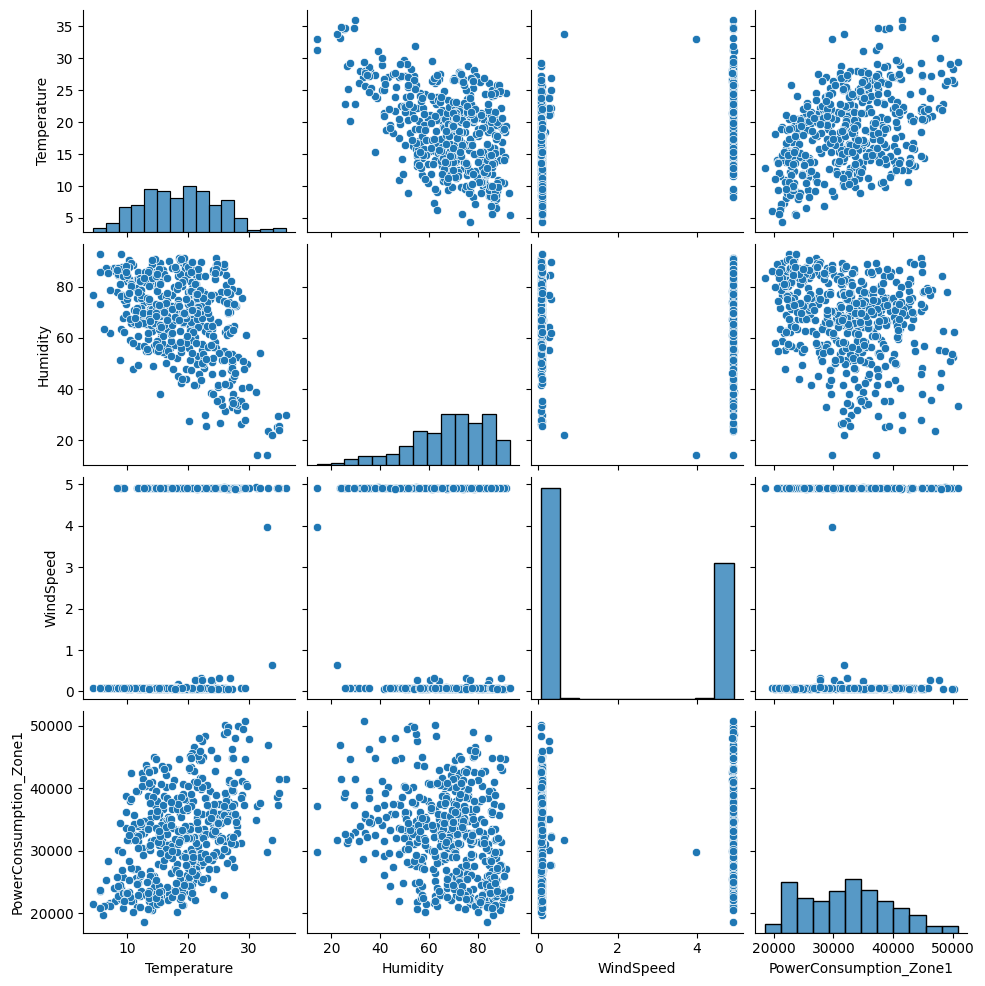

In [15]:
pair_data = df[
    ['Temperature',
     'Humidity',
     'WindSpeed',
     'PowerConsumption_Zone1']
].sample(500, random_state=42)

sns.pairplot(pair_data)
plt.show()

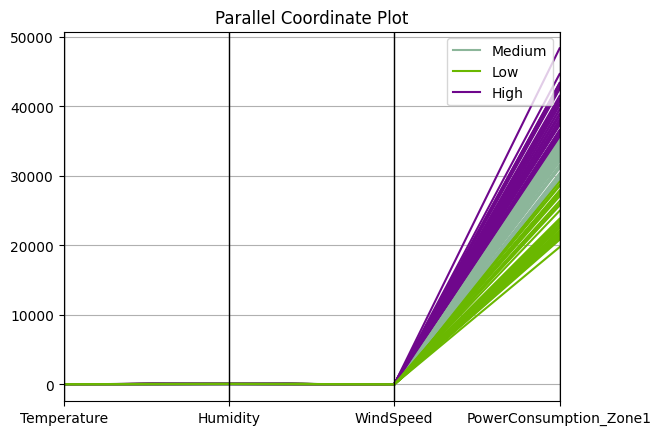

In [16]:
from pandas.plotting import parallel_coordinates

parallel_data = df[
    ['Temperature',
     'Humidity',
     'WindSpeed',
     'PowerConsumption_Zone1']
].sample(100, random_state=42).copy()

parallel_data['Power_Level'] = pd.qcut(
    parallel_data['PowerConsumption_Zone1'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

parallel_coordinates(
    parallel_data,
    'Power_Level'
)

plt.title('Parallel Coordinate Plot')
plt.show()

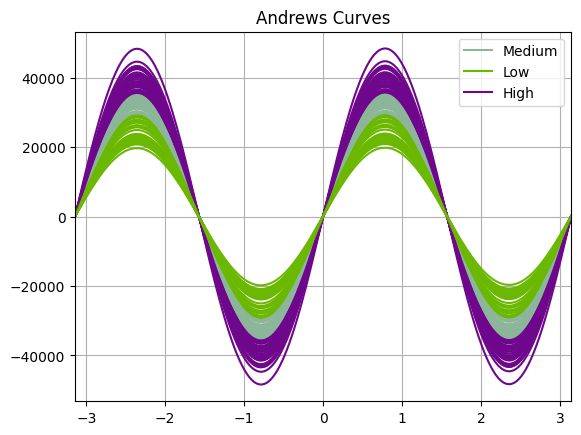

In [17]:
from pandas.plotting import andrews_curves

andrews_data = df[
    ['Temperature',
     'Humidity',
     'WindSpeed',
     'PowerConsumption_Zone1']
].sample(100, random_state=42).copy()

andrews_data['Power_Level'] = pd.qcut(
    andrews_data['PowerConsumption_Zone1'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

andrews_curves(
    andrews_data,
    'Power_Level'
)

plt.title('Andrews Curves')
plt.show()

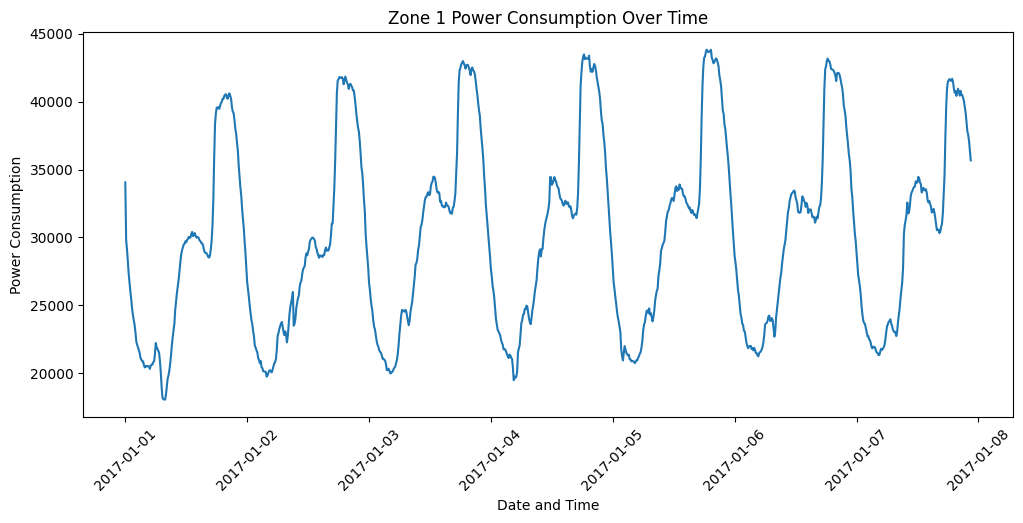

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    df['Datetime'].iloc[:1000],
    df['PowerConsumption_Zone1'].iloc[:1000]
)

plt.xlabel('Date and Time')
plt.ylabel('Power Consumption')
plt.title('Zone 1 Power Consumption Over Time')
plt.xticks(rotation=45)
plt.show()